# Reto 01 — Simulador de máquinas

**Curso:** Aprendizaje por Refuerzo  
**Universidad:** Universidad EIA  
**Estudiante(s):** Simon Garces 
**Correo institucional:** simon.garces@eia.edu.co  
**Fecha:** 24/07/2026


## Objetivo

Construir un simulador de tres máquinas con recompensas normales, estimar sus parámetros a partir de muestras y analizar la relación entre recompensa esperada y variabilidad.

## 1. Preparación del entorno

En esta sección se importan las librerías y se establece una semilla para garantizar que el experimento sea reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

MACHINES = {
    "A1": {"mean": 1.0, "std": 0.5},
    "A2": {"mean": 2.0, "std": 0.5},
    "A3": {"mean": 1.5, "std": 1.5},
}

MACHINES

{'A1': {'mean': 1.0, 'std': 0.5},
 'A2': {'mean': 2.0, 'std': 0.5},
 'A3': {'mean': 1.5, 'std': 1.5}}

## 2. Función de recompensa

Implemente `reward(arm)` para generar una recompensa de la máquina indicada. Explique la validación de entradas y el uso del generador aleatorio.

In [2]:
def reward(arm):
    """Genera una recompensa para la máquina indicada."""

    if arm not in MACHINES:
        raise ValueError(f"Máquina desconocida: {arm}")

    # Buscamos en el diccionario los parámetros (media y desviación)
    # asociados a la máquina solicitada.
    parameters = MACHINES[arm]
    mean = parameters["mean"]
    std = parameters["std"]

    # rng.normal genera un único número aleatorio siguiendo una
    # distribución normal con la media y la desviación de la máquina.
    # Usamos el generador global "rng" (definido en la celda de preparación)
    # para que los resultados sean reproducibles gracias a SEED.
    return rng.normal(mean, std)

### Prueba inicial de la función

Pruebe la función con `A1`, `A2` y `A3`.

In [3]:
# Probamos reward() con cada una de las tres máquinas.
# "for arm in MACHINES" recorre las llaves del diccionario: "A1", "A2", "A3".
for arm in MACHINES:
    # print muestra en pantalla el nombre de la máquina y la recompensa obtenida.
    print(f"{arm}: {reward(arm)}")

A1: 1.1523585398772156
A2: 1.4800079468797522
A3: 2.625676793709686


## 3. Simulación de recompensas

Genere exactamente 1.000 recompensas por máquina y almacene los resultados en un DataFrame con las columnas `machine`, `sample` y `reward`.

In [4]:
N_SAMPLES = 1_000

# Aquí guardaremos una fila (registro) por cada observación generada.
rows = []

# Recorremos cada máquina definida en MACHINES ("A1", "A2", "A3").
for arm in MACHINES:
    # Para cada máquina generamos N_SAMPLES recompensas.
    # range(1, N_SAMPLES + 1) produce los números 1, 2, ..., 1000,
    # que usaremos como el número de muestra (sample).
    for sample_number in range(1, N_SAMPLES + 1):
        # Cada fila es un diccionario con la máquina, el número de
        # muestra y la recompensa obtenida al llamar reward(arm).
        rows.append(
            {
                "machine": arm,
                "sample": sample_number,
                "reward": reward(arm),
            }
        )

# pd.DataFrame convierte la lista de diccionarios en una tabla de datos.
# Debe tener 3.000 filas: 1.000 observaciones x 3 máquinas.
df = pd.DataFrame(rows)

df

,machine,sample,reward
0,A1,1,1.470282
1,A1,2,0.024482
2,A1,3,0.348910
3,A1,4,1.063920
4,A1,5,0.841879
...,...,...,...
2995,A3,996,2.729171
2996,A3,997,0.998819
2997,A3,998,3.373534
2998,A3,999,2.531538


## 4. Verificación de los datos

Verifique el número total de observaciones, los registros por máquina, los tipos de datos y la presencia de valores faltantes.

In [5]:
# df.shape devuelve (número de filas, número de columnas).
# Esperamos (3000, 3): 3.000 observaciones y 3 columnas.
print("Forma del DataFrame (filas, columnas):", df.shape)

# df.head() muestra las primeras 5 filas, útil para revisar rápidamente
# que la estructura de la tabla sea la esperada.
print("\nPrimeras filas:")
print(df.head())

# value_counts() cuenta cuántas veces aparece cada valor en la columna
# "machine", es decir, cuántas observaciones tiene cada máquina.
print("\nObservaciones por máquina:")
print(df["machine"].value_counts())

# isna() marca con True cada celda vacía (faltante) y sum() las cuenta
# por columna. Si todo está en 0, no hay valores faltantes.
print("\nValores faltantes por columna:")
print(df.isna().sum())

Forma del DataFrame (filas, columnas): (3000, 3)

Primeras filas:
  machine  sample    reward
0      A1       1  1.470282
1      A1       2  0.024482
2      A1       3  0.348910
3      A1       4  1.063920
4      A1       5  0.841879

Observaciones por máquina:
machine
A1    1000
A2    1000
A3    1000
Name: count, dtype: int64

Valores faltantes por columna:
machine    0
sample     0
reward     0
dtype: int64


## 5. Estadísticos descriptivos

Calcule la media, desviación estándar y varianza muestral, junto con los valores mínimo y máximo. Compare los valores reales con los estimados.

In [6]:
# groupby("machine") agrupa las filas del DataFrame por máquina, y sobre
# cada grupo calculamos la media y la desviación estándar de "reward".
# ddof=1 indica que se use la corrección de Bessel (dividir entre n-1),
# que es la convención para la desviación estándar MUESTRAL.
summary = df.groupby("machine")["reward"].agg(
    estimated_mean="mean",
    estimated_std=lambda x: x.std(ddof=1),
)

# A cada máquina le agregamos su media y desviación REALES, tomadas
# directamente del diccionario MACHINES (los parámetros verdaderos
# que usamos para simular los datos).
summary["real_mean"] = [MACHINES[arm]["mean"] for arm in summary.index]
summary["real_std"] = [MACHINES[arm]["std"] for arm in summary.index]

# El error absoluto de la media indica qué tan lejos quedó la
# estimación del valor real: |media estimada - media real|.
summary["mean_abs_error"] = (summary["estimated_mean"] - summary["real_mean"]).abs()

# Reordenamos las columnas para que sea más fácil comparar
# lo real contra lo estimado.
summary = summary[
    ["real_mean", "estimated_mean", "mean_abs_error", "real_std", "estimated_std"]
]

summary

,real_mean,estimated_mean,mean_abs_error,real_std,estimated_std
machine,,,,,
A1,1.0,0.984945,0.015055,0.5,0.494330
A2,2.0,1.959570,0.040430,0.5,0.507323
A3,1.5,1.557432,0.057432,1.5,1.528541


## 6. Visualización

Construya una gráfica individual para cada máquina. Incluya la media real, la media estimada, las etiquetas de los ejes y una leyenda.

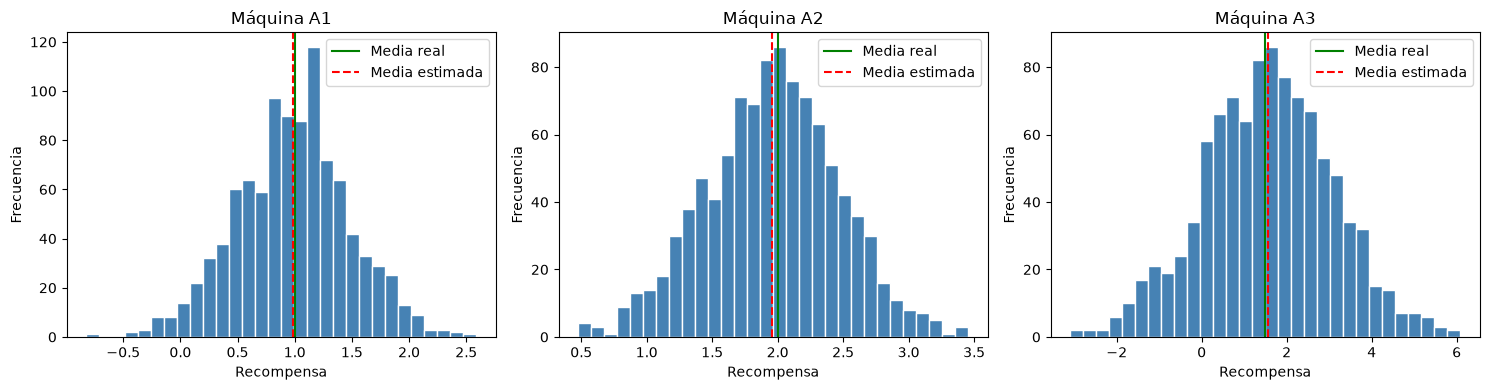

In [7]:
# Creamos una figura con 3 subgráficas (una fila, tres columnas),
# una para cada máquina. figsize controla el tamaño total de la figura.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# zip empareja cada máquina con su eje (axes) correspondiente, para
# dibujar en un subplot distinto en cada iteración del ciclo.
for ax, arm in zip(axes, MACHINES):
    # Filtramos del DataFrame solo las filas de la máquina actual.
    machine_rewards = df.loc[df["machine"] == arm, "reward"]

    # hist dibuja el histograma de las recompensas: bins=30 define
    # cuántas barras (intervalos) se usan para agrupar los datos.
    ax.hist(machine_rewards, bins=30, color="steelblue", edgecolor="white")

    # Tomamos la media real (del diccionario MACHINES) y la media
    # estimada (calculada en la celda anterior) para esta máquina.
    real_mean = MACHINES[arm]["mean"]
    estimated_mean = summary.loc[arm, "estimated_mean"]

    # axvline dibuja una línea vertical en el valor indicado por x.
    # Usamos colores y estilos distintos para diferenciar ambas medias.
    ax.axvline(real_mean, color="green", linestyle="-", label="Media real")
    ax.axvline(estimated_mean, color="red", linestyle="--", label="Media estimada")

    # Título y etiquetas de los ejes para que la gráfica sea legible.
    ax.set_title(f"Máquina {arm}")
    ax.set_xlabel("Recompensa")
    ax.set_ylabel("Frecuencia")
    ax.legend()

# tight_layout evita que los títulos y etiquetas se encimen entre subplots.
plt.tight_layout()
plt.show()

## 7. Experimento con diferentes tamaños de muestra

Compare las estimaciones utilizando 10, 50, 100 y 1.000 observaciones.

In [8]:
SAMPLE_SIZES = [10, 50, 100, 1_000, 4_000, 9_000]

# Aquí guardaremos una fila por cada combinación (máquina, tamaño de muestra).
size_rows = []

# Recorremos cada tamaño de muestra que queremos probar.
for n in SAMPLE_SIZES:
    # Reiniciamos el generador aleatorio con la misma SEED en cada
    # tamaño de muestra, para que el experimento sea reproducible
    # (si volvemos a ejecutar la celda, obtenemos los mismos resultados).
    experiment_rng = np.random.default_rng(SEED)

    # Para cada máquina generamos n recompensas y calculamos sus
    # estadísticos, usando el generador local "experiment_rng".
    for arm in MACHINES:
        samples = experiment_rng.normal(
            MACHINES[arm]["mean"], MACHINES[arm]["std"], size=n
        )

        estimated_mean = samples.mean()
        # ddof=1 solo tiene sentido si hay más de una muestra.
        estimated_std = samples.std(ddof=1) if n > 1 else float("nan")
        real_mean = MACHINES[arm]["mean"]

        size_rows.append(
            {
                "n": n,
                "machine": arm,
                "estimated_mean": estimated_mean,
                "estimated_std": estimated_std,
                "real_mean": real_mean,
                # Error absoluto: qué tan lejos quedó la media estimada
                # de la media real, para este tamaño de muestra.
                "abs_error": abs(estimated_mean - real_mean),
            }
        )

# Convertimos la lista de resultados en una tabla y la ordenamos por
# máquina y luego por tamaño de muestra, para leerla más fácilmente.
size_df = pd.DataFrame(size_rows).sort_values(["machine", "n"]).reset_index(drop=True)

size_df

,n,machine,estimated_mean,estimated_std,real_mean,abs_error
0,10,A1,0.832214,0.466747,1.0,0.167786
1,50,A1,1.045606,0.384139,1.0,0.045606
2,100,A1,0.974865,0.388339,1.0,0.025135
3,1000,A1,0.985554,0.494609,1.0,0.014446
4,4000,A1,0.990247,0.499929,1.0,0.009753
5,9000,A1,0.996608,0.501382,1.0,0.003392
6,10,A2,2.134854,0.361803,2.0,0.134854
7,50,A2,1.904125,0.383297,2.0,0.095875
8,100,A2,1.994684,0.489757,2.0,0.005316
9,1000,A2,1.959311,0.507271,2.0,0.040689


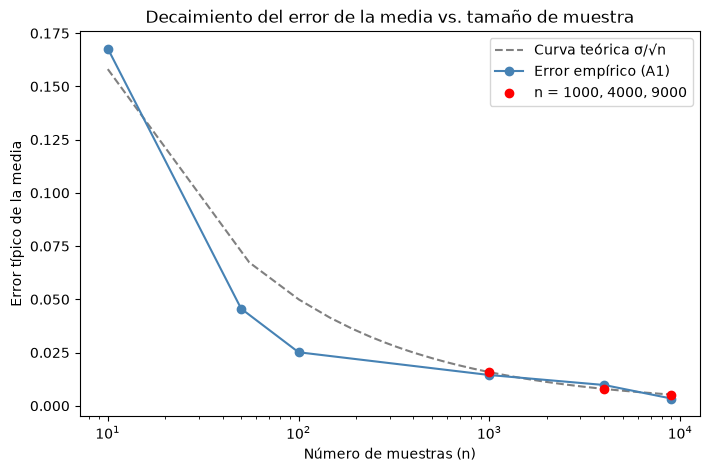

In [9]:
# En esta celda visualizamos cómo decae el error de la media al
# aumentar el número de muestras (n), y lo comparamos con la curva
# teórica del error estándar de la media: sigma / sqrt(n).

# sigma=0.5 corresponde a la desviación estándar real de la máquina A1.
sigma_a1 = MACHINES["A1"]["std"]

# Tomamos el error absoluto empírico de A1 (calculado en la celda
# anterior) para cada tamaño de muestra n.
a1_errors = size_df[size_df["machine"] == "A1"].sort_values("n")

# np.linspace crea muchos puntos entre el n más chico y el más grande,
# para dibujar la curva teórica como una línea suave.
n_grid = np.linspace(min(SAMPLE_SIZES), max(SAMPLE_SIZES), 200)
theoretical_error = sigma_a1 / np.sqrt(n_grid)

fig, ax = plt.subplots(figsize=(8, 5))

# Curva teórica sigma/sqrt(n): así se espera que decaiga el error
# de la media cuando el tamaño de muestra n crece.
ax.plot(n_grid, theoretical_error, color="gray", linestyle="--", label="Curva teórica σ/√n")

# Puntos con el error empírico observado en la simulación para A1.
ax.plot(a1_errors["n"], a1_errors["abs_error"], "o-", color="steelblue", label="Error empírico (A1)")

# Marcamos con puntos rojos los tamaños de muestra n=1000, 4000 y 9000
# sobre la curva teórica, para resaltarlos visualmente.
highlight_n = [1_000, 4_000, 9_000]
highlight_error = sigma_a1 / np.sqrt(highlight_n)
ax.scatter(highlight_n, highlight_error, color="red", zorder=5, label="n = 1000, 4000, 9000")

# set_xscale("log") usa escala logarítmica en el eje x, útil porque
# los tamaños de muestra van de 10 a 9000 (varios órdenes de magnitud).
ax.set_xscale("log")
ax.set_xlabel("Número de muestras (n)")
ax.set_ylabel("Error típico de la media")
ax.set_title("Decaimiento del error de la media vs. tamaño de muestra")
ax.legend()
plt.show()

# Dato factual (curva teórica sigma/sqrt(n), sigma=0.5):
# error(1000) = 0.5/sqrt(1000) = 0.01581
# error(4000) = 0.5/sqrt(4000) = 0.00791  -> la mitad de error(1000)
# error(9000) = 0.5/sqrt(9000) = 0.00527  -> un tercio de error(1000)

## 8. Interpretación de resultados

1. ¿Cuál máquina tuvo la mayor recompensa media estimada? R/ Brazo A2 con 1.960
2. ¿La máquina con mayor media estimada coincide con la de mayor media real? R/ si, la media ral del brazo A2 era de 2 osea que solo se separan por 0.04, lo que en mi opinion es bastante bien.
3. ¿Cuál presentó mayor desviación y varianza? R/ A3 con una desviacion estandar de 1.529
4. ¿Por qué A3 puede considerarse más riesgosa?R/ porque tiene una std alta y las recompenzas van a tener la mayor varianza jugada a jugada. Es decir A3 tiene mayor retorno esperado mayor volatilidad 
5. ¿Una recompensa individual alta implica que la máquina sea mejor? R/ Retomando lo dicho en lsa anterior pregunta, se puede decir que no, o al menos en el contexto de un casino o una maquinita de juegos, en mi opinion y segun la data, es preferible una recompenza menor pero reproducible, como en el caso de A2 que tiene la mejor media y practicamente empatada con A1 en la varianza. All pese a que la recompensa es menor que en A3 es mucho mejor en media pero no es consistente tirada a tirada
6. ¿Cómo influye el tamaño de la muestra? el error cae al aumentar n, en A1 pasa de 0.168 con n=10 y en n=9000 cae a 0.003. para reducir el error se requiere cuadruplicar n pero con los escenarios simulados vemos que a parir de n=1000 ya tiene un error bastante aceptable 
7. Si las medias fueran desconocidas, ¿cómo decidiría qué máquina elegir? R/ saría la media estimada acumulada hasta el momento, pero si tengo pocas observaciones consideraria tambien cuánta incertidumbre hay (varianza, cuántas veces he probado esa máquina). Es el dilema explorar vs. explotar, seguir probando para reducir incertidumbre vs. quedarme con la que de momento parece mejor
8. ¿Qué cambiaría utilizando solamente 10 recompensas? los errores se disparan en un orden de magnitud de 5 a 10 veces que con n=1000. por ejemplo para A3 especificamente la desviacion standar queda en 0.860 muy lejos de la real 1.5

### Respuestas

Escriba aquí el análisis sustentado en los resultados obtenidos.

## 9. Uso de inteligencia artificial

**Herramienta utilizada:** Claude (Anthropic), en la interfaz de chat para resolver dudas conceptuales y como agente de codificación en VS Code para implementar las celdas.

**Prompts o preguntas principales:**
1. Cómo configurar el entorno del repositorio (venv con Python 3.12) y ejecutar pytest.
2. Qué significa el término n−1 (corrección de Bessel) y por qué el estimador muestral usa esas ecuaciones.
3. Si aumentar el número de corridas (2000, 3000, 9000) mejora las estimaciones y en qué proporción.
4. Implementación de reward(), la simulación de 1000 muestras, la tabla real vs. estimado y los histogramas.
5. Realizacion de un pdf (adjunto) Para la explicacion de conceptos vistos para el reto 1 y 2 

**Sugerencias recibidas:** entorno virtual con Python 3.12; implementar reward() con el generador de NumPy y validación de la máquina; usar ddof=1 para la desviación muestral; extender el experimento de tamaños de muestra y graficar el error ∝ 1/√n para visualizar los rendimientos decrecientes.

**Cambios realizados manualmente:** generar el enviroment pidiendole a la ia que copie el del dev cntainer 

**Sugerencias descartadas:** Usar el dev container. No tomar en cuenta la recomendacion de que el error se haria insignificante a medida que aumenta el numero n de intentos

**Forma de validación:** ejecución de `pytest` en verde desde la raíz del repositorio; "Restart Kernel and Run All Cells" sin errores; verificación de que las medias estimadas se acercan a las reales; revisión celda por celda del código generado.

## 10. Conclusiones

1. Los parametros estimados de una maquina se acercan al valor real a  medida que aumenta el tampano de la muestra.
2.  media y varianza son propiedades independientes, no toda máquina con buen promedio es riesgosa, ni toda máquina riesgosa compensa ese riesgo con mejor recompensa esperad. Esto ilustra por que, en un problema real de bandits donde no se conocen los parámetros verdaderos, decidir qué máquina jugar exige balancear exploración para reducir la incertidumbre de la estimación y explotación para aprovechar la mejor opción conocida hasta el momento.

